In [1]:
from ppafm.io import loadXYZ
from ppafm.ocl.AFMulator import AFMulator
from ppafm.ocl.oclUtils import init_env
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import argrelextrema
import numpy as np
from collections import defaultdict

def plot_surface(img, vmin=None, vmax=None):
    plt.imshow(img.T, vmin=vmin, vmax=vmax)


def compute_imgs(path_surface, params="materials/params_code.ini"):
    init_env(i_platform=0)
    xyzs, Zs, qs, _ = loadXYZ(path_surface)
    afmulator = AFMulator.from_params(params)
    afm_images = afmulator(xyzs, Zs, qs)
    
    return afmulator, afm_images


def get_minimum_surface(afmulator, afm_images, xy=(32, 14), sigma=4, generate_plots=False):
    xy = np.array(xy)
    # Actual height
    z = np.linspace(
                afmulator.scan_window[0][2],
                afmulator.scan_window[1][2] - afmulator.df_steps * afmulator.dz,
                afmulator.scan_dim[2] - afmulator.df_steps + 1,
    )
    
    # Get all minima in the z direction and only keep the highest one
    minima = np.array(argrelextrema(afm_images, np.less_equal, axis=2)).T
    minima_dict = defaultdict(list)
    for xx, yy, zz in minima:
        minima_dict[xx, yy].append(zz)
        minima_dict[xx, yy] = [max(minima_dict[xx, yy])]
    
    argmin_image = np.zeros(afm_images.shape[0:-1], dtype=int)
    for pixel, val in minima_dict.items():
        argmin_image[pixel] = int(val[0])
    
    # Convert index to actual height
    min_image = z[argmin_image]
    blurred_image = gaussian_filter(min_image, sigma=sigma)
    
    if generate_plots:
        vmin = np.min(min_image)
        vmax = np.max(min_image)
        plt.rcParams["figure.figsize"] =  [20, 10]

        plt.subplots(1, 2)

        plt.subplot(1, 2, 1)
        plt.title("Minimas of each Pixel")
        plot_surface(min_image, vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.scatter(xy[0], xy[1], color='red')
        plt.tight_layout()
        plt.axvline(xy[0], color='orange')
        plt.axhline(xy[1], color='magenta')
        
        plt.subplot(1, 2, 2)
        plt.title(f"Blurred version {sigma=}")
        plot_surface(blurred_image, vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.scatter(xy[0], xy[1], color='red')
        plt.tight_layout()
        plt.axvline(xy[0], color='orange')
        plt.axhline(xy[1], color='magenta')
        
        plt.show()
        
        minima = argrelextrema(afm_images[xy[0], xy[1]], np.less_equal)
        
        plt.title(f"df curve for pixel {xy}")
        plt.xlabel("Distance / (Å)")
        plt.ylabel("df / (Hz)")
        plt.plot(z, afm_images[xy[0], xy[1], :])
        for minimum in minima:
            plt.scatter(z[minimum], afm_images[xy[0], xy[1], minimum], color="red")
            
        plt.show()
        
        plt.title("Slice in x direction")
        plt.plot(gaussian_filter(min_image[:,xy[1]], sigma=sigma))
        plt.plot(min_image[:,xy[1]], color="magenta")
        plt.ylabel("Height / (Å)")
        plt.show()
        
        plt.title("Slice in y direction")
        plt.plot(gaussian_filter(min_image[xy[0],:], sigma=sigma))
        plt.plot(min_image[xy[0], :], color="orange")
        plt.ylabel("Height / (Å)")
        plt.show()
    
    return min_image, blurred_image, z

 PACKAGE_PATH =  /home/henry/Documents/SharedDocuments/Uni/TU/InterdisciplinaryProject/repo/.venv_ip/lib/python3.12/site-packages/ppafm
 CPP_PATH     =  /home/henry/Documents/SharedDocuments/Uni/TU/InterdisciplinaryProject/repo/.venv_ip/lib/python3.12/site-packages/ppafm/cpp


Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


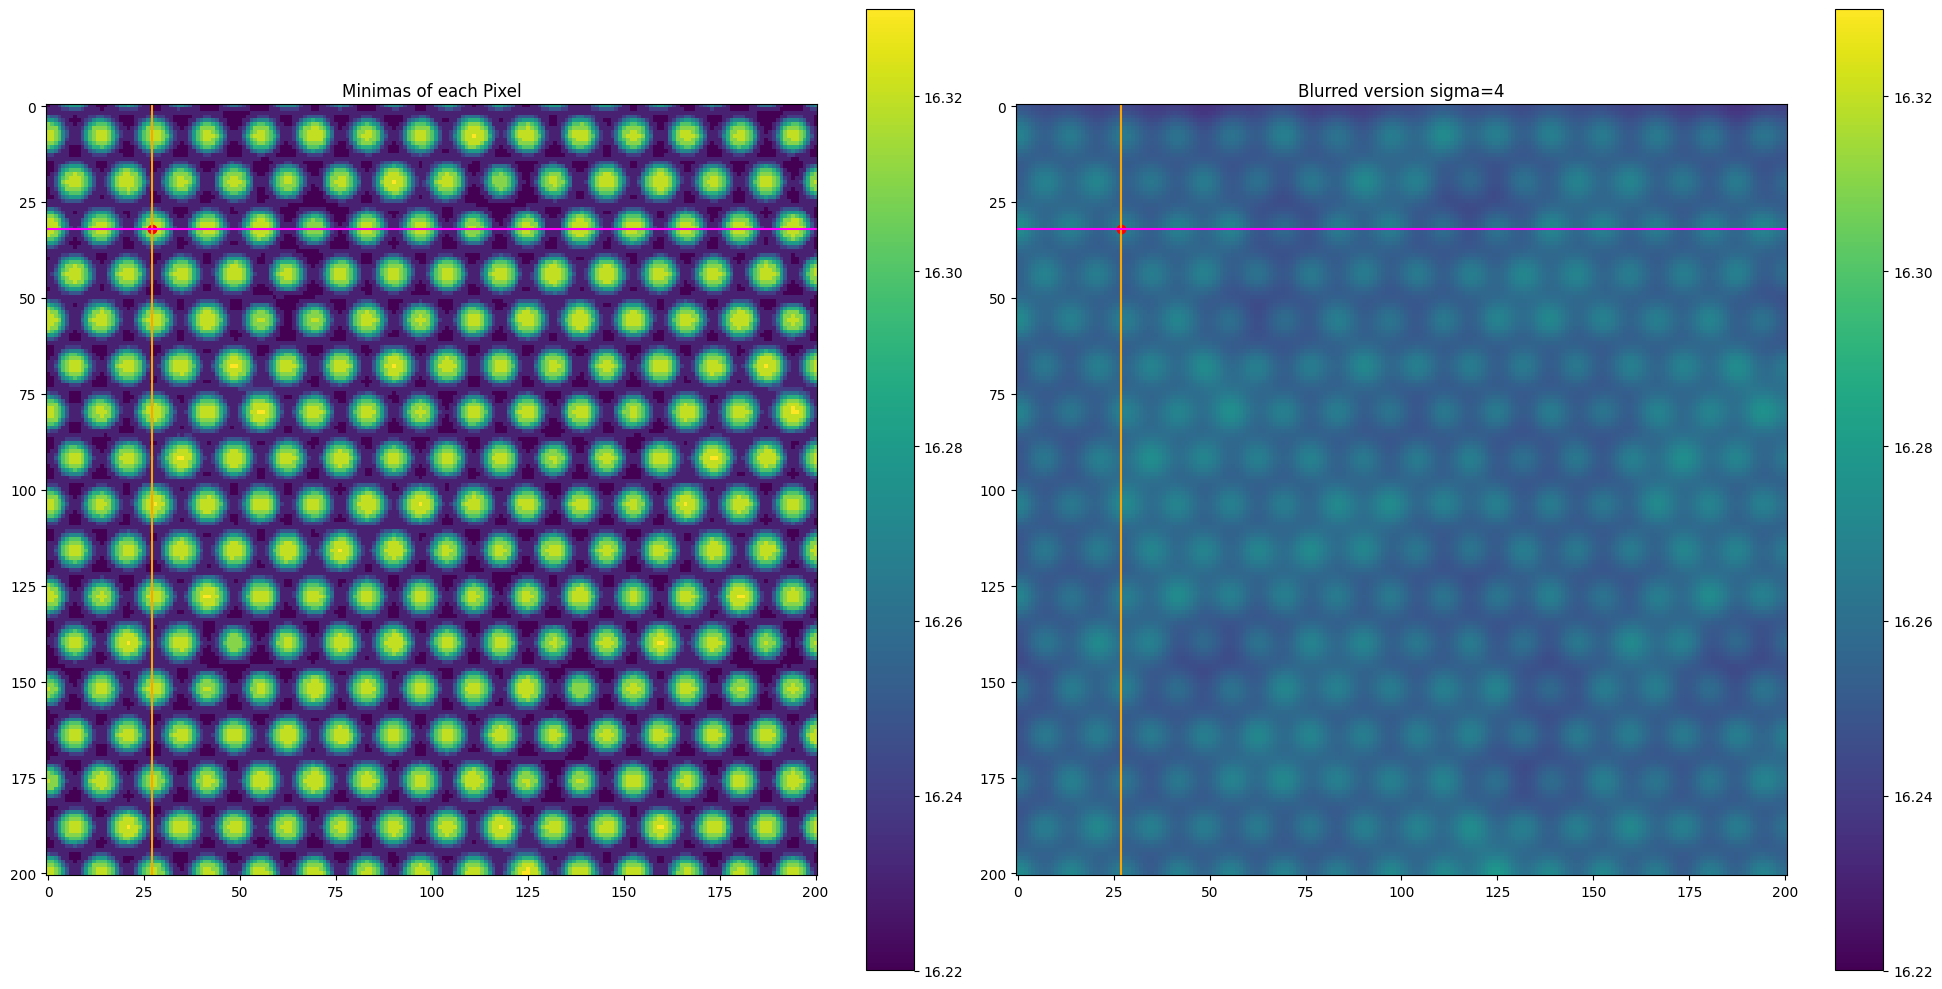

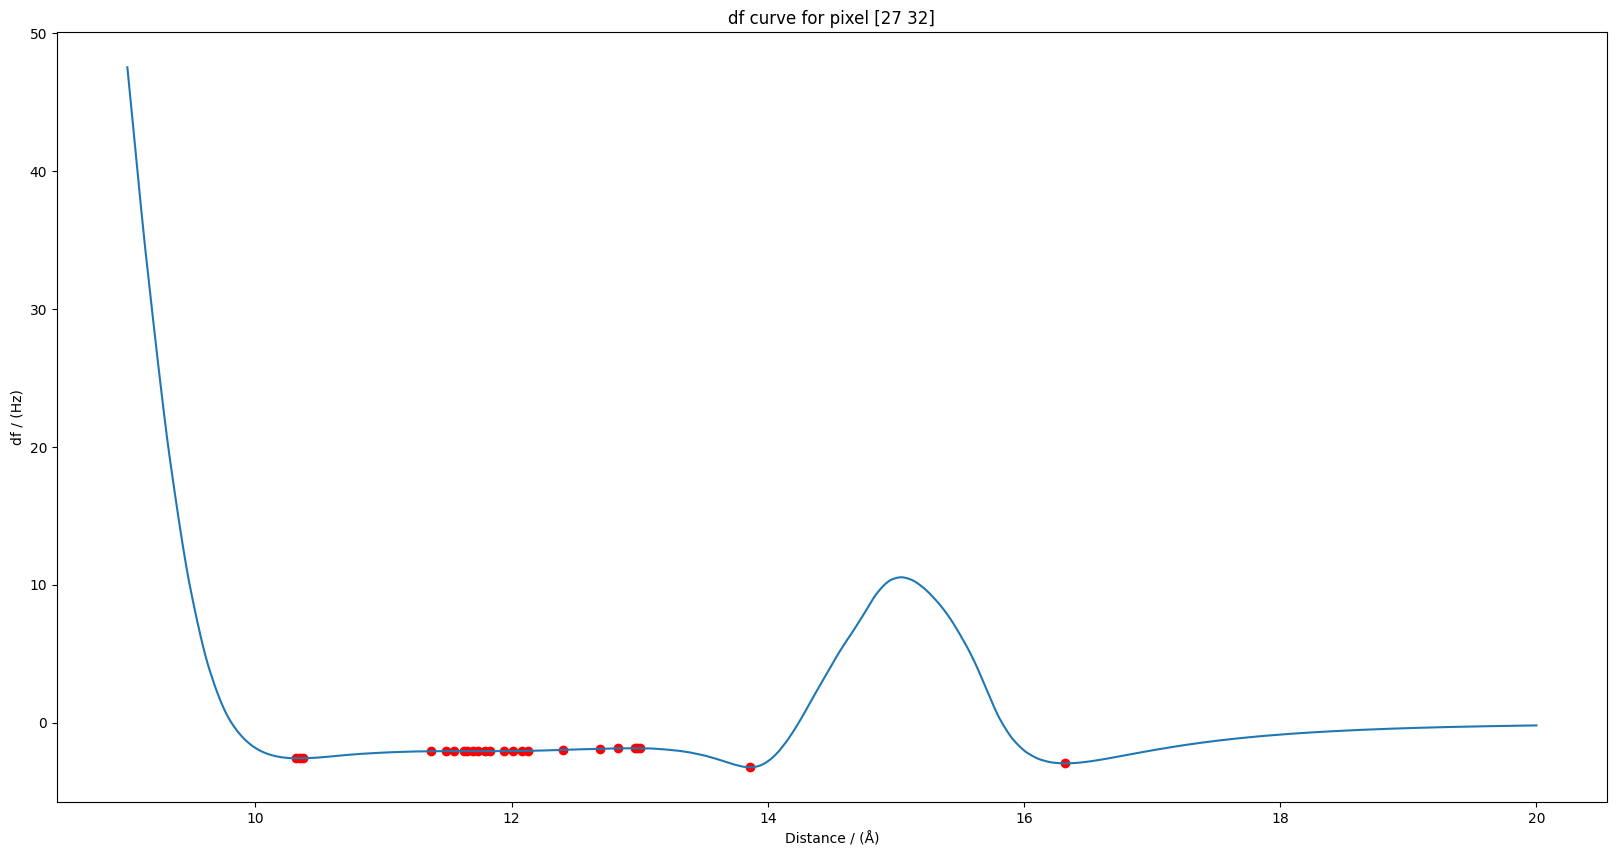

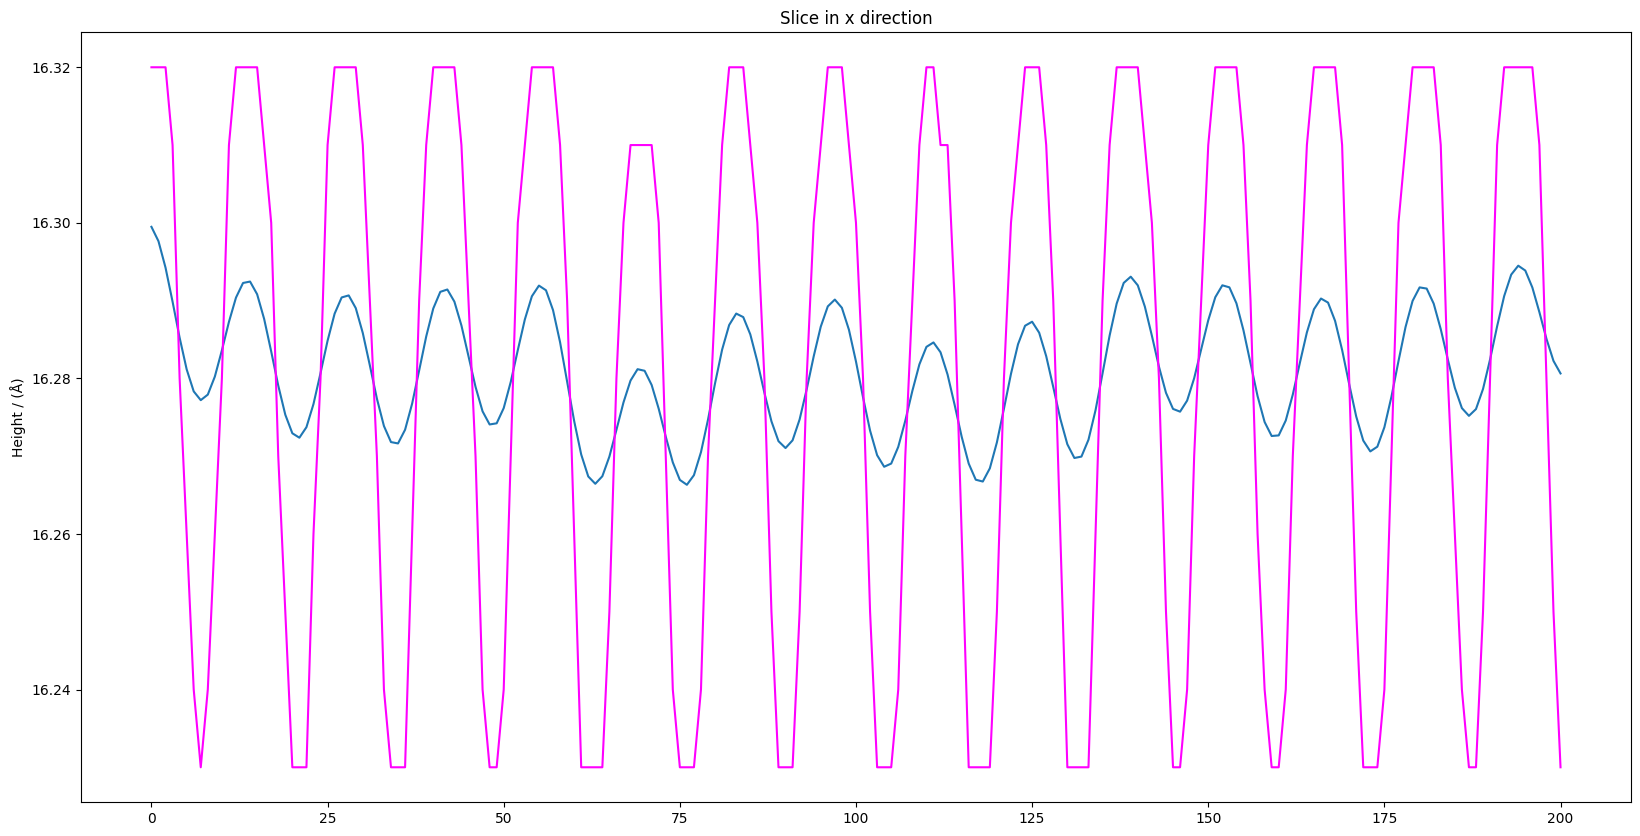

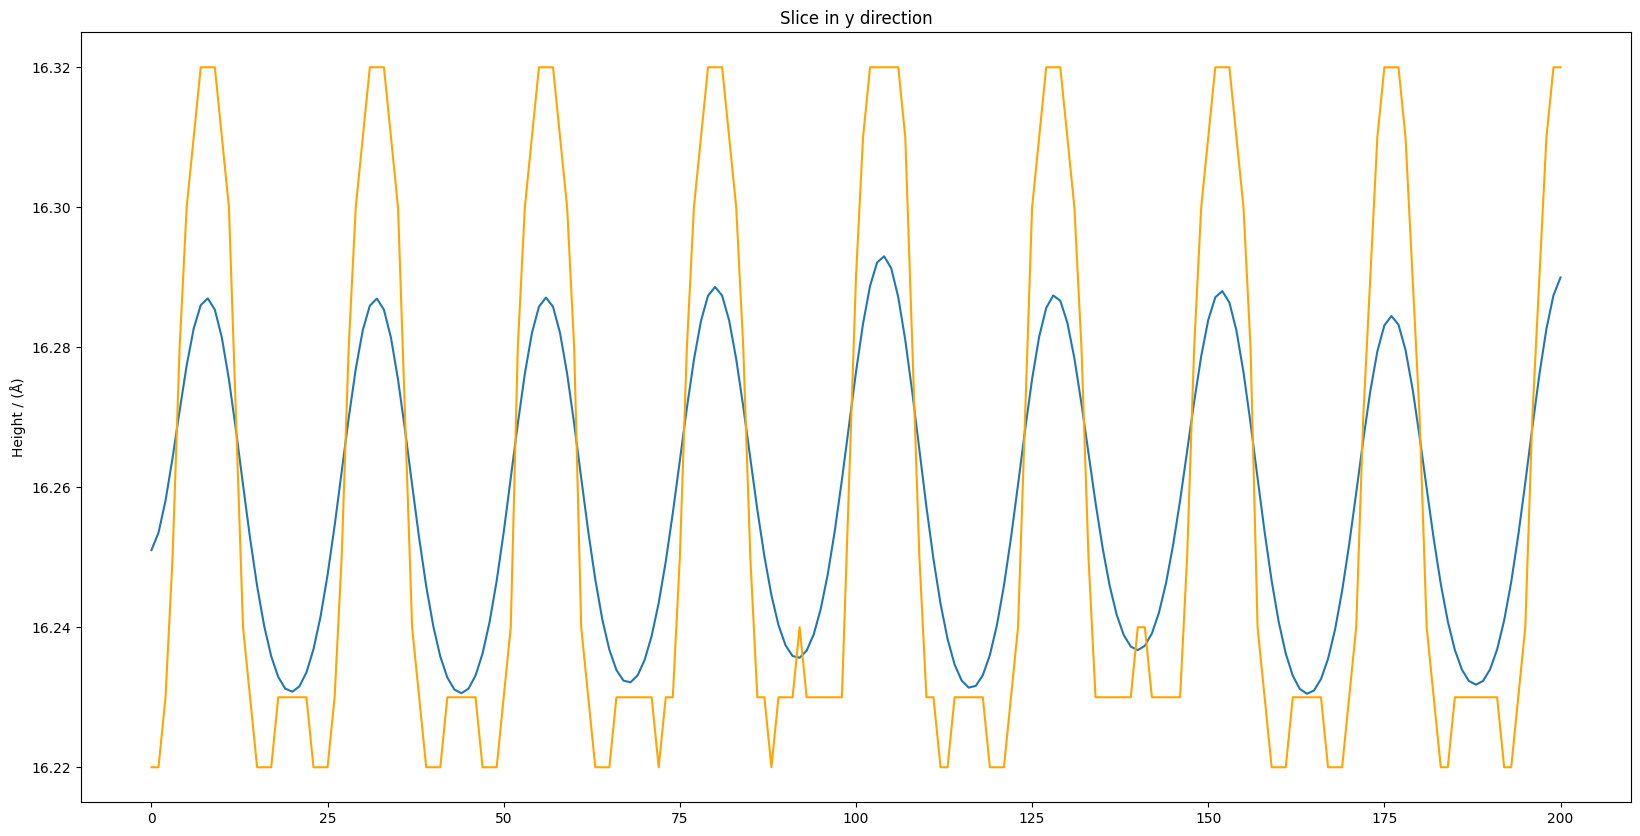

In [2]:
afmulator, afm_images = compute_imgs("materials/pt_111_small.xyz")
afm_images = afm_images[:,::-1,::-1]

# pt_111_smal_1_3_vacancies.xyz
xy_3_vacancy = (118, 69)
xy_1_vacancy = (21, 20)

# pt_111_small_rows_missing.xyz
xy_2row_corner = (103, 67)
xy_3row_corner = (146, 67)
xy_3row_middle = (171, 44)
xy_reference = (77, 67)

#pt_111_small_single_adatom
xy_adatom = (27, 32)

xy_test = (162, 44)
#xy_test = (200, 200)

min_image, blurred_image, z = get_minimum_surface(afmulator, afm_images, xy=xy_adatom, sigma=4, generate_plots=True)

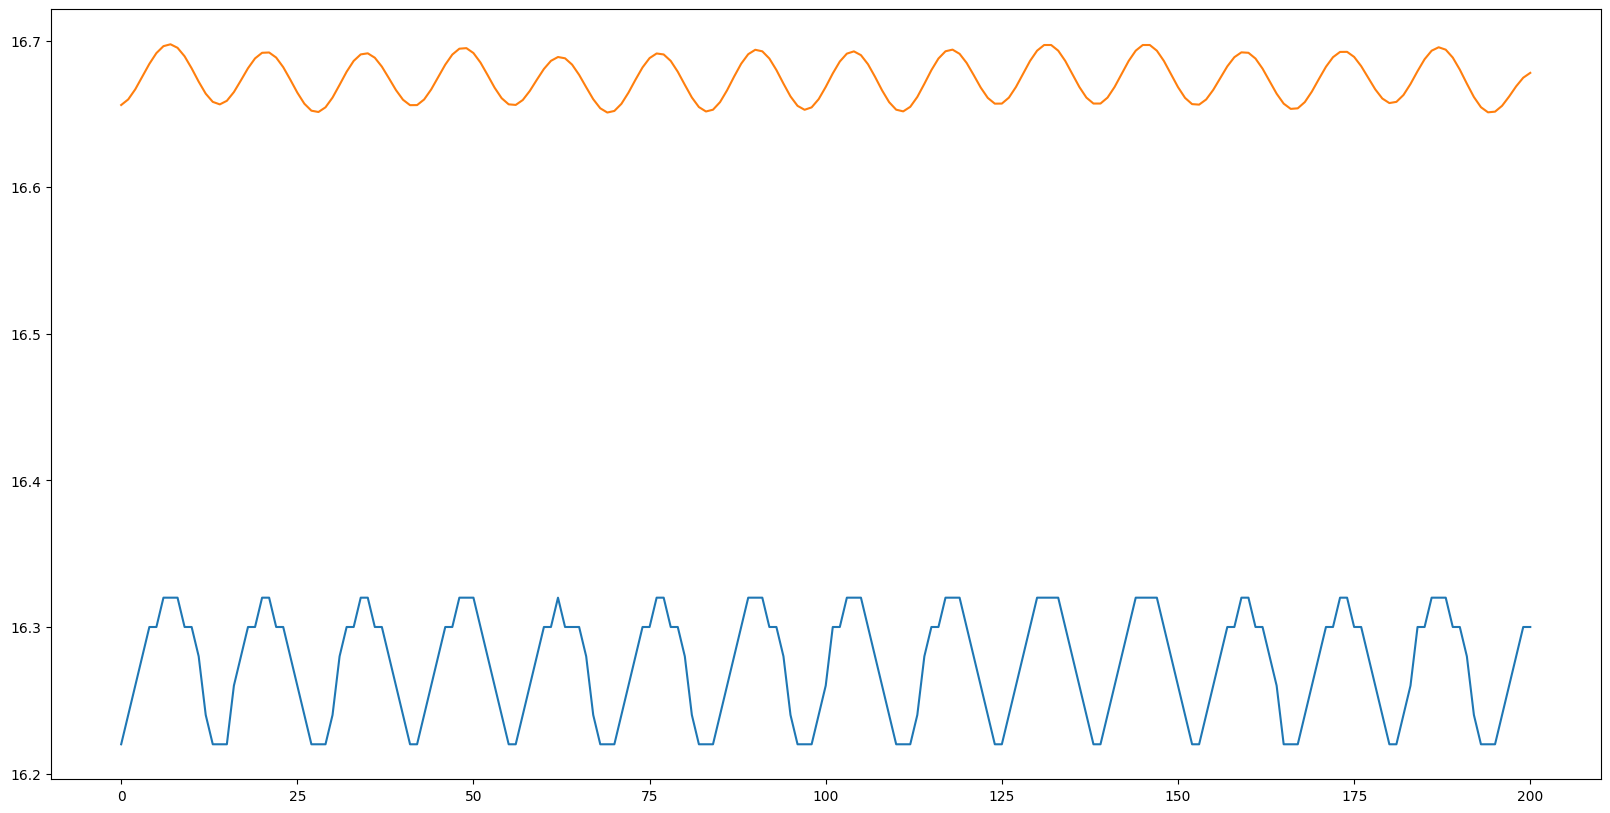

In [7]:
plt.plot(min_image[:,44])
plt.plot(gaussian_filter(min_image[:,44]+0.4, sigma=3))
#plt.plot(gaussian_filter(min_image[:,162], sigma=6))
plt.show()
#gaussian_filter(min_image[171,:], sigma=3)

# Q-learning

In [ ]:
class Environment:
    def __init__(self):
        self.grid = np.zeros((4, 12))
        self.grid[3, 11] = 2
        
        self.agent_position = np.array([3,0]) #Position([3,0]) #np.array([3,0])
    
    def __str__(self):
        grid = copy(self.grid)
        grid[*self.agent_position] = 7
        return np.array2string(grid)
        
    def __repr__(self):
        grid = self.grid
        grid[*self.agent_position] = 7
        return np.array2string(grid)
    
    def process_action(self, action):
        if action == "down":
            if self.agent_position[0] == 2 and 0 < self.agent_position[1] < 11:
                self.agent_position = [3,0]
                return False, self.agent_position, -100
            elif self.agent_position[0] == 3:
                self.agent_position[0] = 3
            else:
                self.agent_position[0] += 1
        elif action == "up":
            if self.agent_position[0] == 0:
                self.agent_position[0] = 0
            else:
                self.agent_position[0] -= 1
        elif action == "right":
            if self.agent_position[0] == 3 and self.agent_position[1] == 0:
                self.agent_position = [3,0]
                return False, self.agent_position, -100
            elif self.agent_position[1] == 11:
                self.agent_position[1] = 11
            else:
                self.agent_position[1] += 1
        elif action == "left":
            if self.agent_position[1] == 0:
                self.agent_position[1] = 0
            else:
                self.agent_position[1] -= 1

        if self.grid[*self.agent_position] == 2:
            return True, self.agent_position, -1

        return False, self.agent_position, -1

class QClass:
    def __init__(self, eps):
        self.q = np.random.rand(4, 12, 4)
        self.q[3, 11, :] = 0
        self.eps = eps
        
    def get_eps_greedy(self, state):
        if np.random.rand() < self.eps:
            return np.random.choice([0, 1, 2, 3])
        else:
            return self.get_max_action(state)
        
    def get_max(self, state):
        return self.q[*state, :].max()
    
    def get_max_action(self, state):
        return np.random.choice(np.flatnonzero(self.q[*state, :] == self.q[*state, :].max()))
        
    def __getitem__(self, item):
        return self.q[*item]
    
    def __setitem__(self, key, value):
        self.q[*key] = value
        
    def print_best_actions(self):
        grid_with_actions = []
        for y in range(4):
            row = []
            for x in range(12):
                row.append(int_to_action[self.get_max_action((y, x))][0])
            grid_with_actions.append(row)
        print(np.array(grid_with_actions))

def q_learning(alpha = 0.3, eps = 0.1, gamma = 0.99, train_cycles = 100):
    sum_rewards_ql = np.zeros(200)
    for train_cycle in range(train_cycles):
        print(f"{train_cycle = }")
        Q = QClass(eps)
    
        for episode in range(200):
            env = CliffEnvironment()
            terminal_state_reached = False
            S = env.agent_position.copy()
            
            i=0
            sum_reward = 0
            while not terminal_state_reached:
                action = Q.get_eps_greedy(S)
                terminal_state_reached, S_prime, reward = env.process_action(int_to_action[action])
                S_prime = S_prime.copy()
                sum_reward += reward
                
                Q[*S, action] = Q[*S, action] + alpha * (reward + gamma*Q.get_max(S_prime) - Q[*S, action])
                S = S_prime
                
                if i > 10000:
                    break
                i+=1
                
            sum_rewards_ql[episode] += sum_reward
            
    sum_rewards_ql /= train_cycles
    return sum_rewards_ql

sum_rewards_ql = q_learning()